In [42]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0, Xception
from tensorflow.keras.layers import (
    Dense, GlobalAveragePooling2D, Concatenate, Input,
    BatchNormalization, Dropout, Conv2D, Multiply,
    GlobalMaxPooling2D, Reshape, Activation, Add,
    Lambda, Flatten
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from mtcnn import MTCNN

In [14]:
# ══════════════════════════════════════════════════════════════════
# 1. CONFIGURATION
# ══════════════════════════════════════════════════════════════════
CONFIG = {
    'parent_dir'   : '/Users/raisulislam/Desktop/deepfake/deepfake_dataset',
    'model_path'   : '/Users/raisulislam/Desktop/deepfake_detector_v2.keras',
    'img_size'     : (224, 224),
    'batch_size'   : 32,
    'epochs'       : 20,
    'learning_rate': 1e-4,
    'threshold'    : 0.5,
}

In [16]:
# ══════════════════════════════════════════════════════════════════
# 2. FACE EXTRACTION WITH MTCNN
# ══════════════════════════════════════════════════════════════════
detector = MTCNN()

def extract_face(image_path, target_size=(224, 224)):
    """
    Detect and crop face from image.
    Falls back to full image resize if no face found.
    """
    img = cv2.imread(image_path)
    if img is None:
        return None

    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    detections = detector.detect_faces(rgb)

    if detections:
        # Use the highest-confidence detection
        best = max(detections, key=lambda d: d['confidence'])
        x, y, w, h = best['box']
        # Add 20% margin around face
        margin = int(0.2 * max(w, h))
        x1 = max(0, x - margin)
        y1 = max(0, y - margin)
        x2 = min(rgb.shape[1], x + w + margin)
        y2 = min(rgb.shape[0], y + h + margin)
        face = rgb[y1:y2, x1:x2]
    else:
        face = rgb  # fallback

    face = cv2.resize(face, target_size)
    return face

In [18]:
# ══════════════════════════════════════════════════════════════════
# 3. FREQUENCY DOMAIN BRANCH (DCT Features)
# ══════════════════════════════════════════════════════════════════
def compute_dct_features(image_batch):
    """
    Convert RGB image batch to DCT frequency features.
    Deepfakes leave compression artifacts detectable in frequency domain.
    """
    # Convert to grayscale
    gray = tf.image.rgb_to_grayscale(image_batch)
    gray = tf.squeeze(gray, axis=-1)
    # Cast to float32
    gray = tf.cast(gray, tf.float32)
    # Apply DCT along last axis twice (2D DCT approximation)
    dct1 = tf.signal.dct(gray, type=2, norm='ortho')
    dct2 = tf.signal.dct(tf.transpose(dct1, [0, 2, 1]), type=2, norm='ortho')
    dct2d = tf.transpose(dct2, [0, 2, 1])
    # Log-magnitude spectrum
    magnitude = tf.math.log(tf.abs(dct2d) + 1e-8)
    # Expand dims to treat as single-channel image
    return tf.expand_dims(magnitude, axis=-1)

def build_dct_branch(input_tensor):
    """Small CNN to process DCT features."""
    dct = Lambda(compute_dct_features, name='dct_transform')(input_tensor)
    x = Conv2D(32, (3,3), activation='relu', padding='same')(dct)
    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    return x

In [20]:
# ══════════════════════════════════════════════════════════════════
# 4. CHANNEL ATTENTION (CBAM-style)
# ══════════════════════════════════════════════════════════════════
def channel_attention(feature_map, ratio=8):
    """
    Squeeze-and-Excitation style attention.
    Forces the model to focus on manipulation-relevant channels.
    """
    channels = feature_map.shape[-1]

    # Squeeze
    avg_pool = GlobalAveragePooling2D()(feature_map)
    max_pool = GlobalMaxPooling2D()(feature_map)

    # Excitation
    avg_out = Dense(channels // ratio, activation='relu')(avg_pool)
    avg_out = Dense(channels, activation='sigmoid')(avg_out)

    max_out = Dense(channels // ratio, activation='relu')(max_pool)
    max_out = Dense(channels, activation='sigmoid')(max_out)

    attention = Add()([avg_out, max_out])
    attention = Activation('sigmoid')(attention)
    attention = Reshape((1, 1, channels))(attention)

    return Multiply()([feature_map, attention])

In [22]:
# ══════════════════════════════════════════════════════════════════
# 5. FULL MODEL ARCHITECTURE
# ══════════════════════════════════════════════════════════════════
def build_model(input_shape=(224, 224, 3)):
    input_tensor = Input(shape=input_shape, name='image_input')

    # ── Branch 1: EfficientNetB0 (spatial texture features) ──
    eff_base = EfficientNetB0(
        weights='imagenet', include_top=False,
        input_shape=input_shape
    )
    eff_base.trainable = False  # freeze initially
    eff_features = eff_base(input_tensor, training=False)
    eff_att      = channel_attention(eff_features)          # attention
    x1 = GlobalAveragePooling2D()(eff_att)
    x1 = BatchNormalization()(x1)

    # ── Branch 2: Xception (depthwise separable — good for blending artifacts) ──
    xcp_base = Xception(
        weights='imagenet', include_top=False,
        input_shape=input_shape
    )
    xcp_base.trainable = False  # freeze initially
    xcp_features = xcp_base(input_tensor, training=False)
    xcp_att      = channel_attention(xcp_features)          # attention
    x2 = GlobalAveragePooling2D()(xcp_att)
    x2 = BatchNormalization()(x2)

    # ── Branch 3: DCT Frequency Domain ──
    x3 = build_dct_branch(input_tensor)

    # ── Fusion Head (matches your diagram) ──
    merged = Concatenate(name='fusion')([x1, x2, x3])

    x = Dense(256, activation='relu')(merged)
    x = Dropout(0.5)(x)
    x = BatchNormalization()(x)

    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)

    output = Dense(1, activation='sigmoid', name='prediction')(x)

    model = Model(inputs=input_tensor, outputs=output)
    return model

model = build_model()
model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ image_input[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception            │ (None, 7, 7,      │ 20,861,480 │ image_input[0][0] │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ xception[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 2048)      │          0 │ xception[0][0]    │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 160)       │    204,960 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 160)       │    204,960 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 256)       │    524,544 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 256)       │    524,544 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 1280)      │    206,080 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 1280)      │    206,080 │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 2048)      │    526,336 │ dense_18[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 2048)      │    526,336 │ dense_20[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1280)      │          0 │ dense_15[0][0],   │
│                     │                   │            │ dense_17[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_13 (Add)        │ (None, 2048)      │          0 │ dense_19[0][0],   │
│                     │                   │            │ dense_21[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1280)      │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 2048)      │          0 │ add_13[0][0]      │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 28,769,932 (109.75 MB)

 Trainable params: 3,851,585 (14.69 MB)

 Non-trainable params: 24,918,347 (95.06 MB)

In [24]:

# ══════════════════════════════════════════════════════════════════
# 6. CLASS WEIGHTS (fix imbalance)
# ══════════════════════════════════════════════════════════════════
real_dir     = os.path.join(CONFIG['parent_dir'], 'real')
deepfake_dir = os.path.join(CONFIG['parent_dir'], 'deepfake')

real_count     = len(os.listdir(real_dir))
deepfake_count = len(os.listdir(deepfake_dir))
total          = real_count + deepfake_count

class_weight = {
    0: total / (2 * real_count),
    1: total / (2 * deepfake_count),
}
print(f"Real: {real_count} | Deepfake: {deepfake_count}")
print(f"Class weights → Real: {class_weight[0]:.2f}, Deepfake: {class_weight[1]:.2f}")

Real: 3745 | Deepfake: 104201
Class weights → Real: 14.41, Deepfake: 0.52


In [26]:
# ══════════════════════════════════════════════════════════════════
# 7. DATA GENERATORS
# ══════════════════════════════════════════════════════════════════
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2],
    shear_range=0.1,
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
)

train_gen = train_datagen.flow_from_directory(
    CONFIG['parent_dir'],
    target_size=CONFIG['img_size'],
    batch_size=CONFIG['batch_size'],
    class_mode='binary',
    subset='training',
    shuffle=True,
)

val_gen = val_datagen.flow_from_directory(
    CONFIG['parent_dir'],
    target_size=CONFIG['img_size'],
    batch_size=CONFIG['batch_size'],
    class_mode='binary',
    subset='validation',
    shuffle=False,
)

python(5996) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Found 86356 images belonging to 2 classes.
Found 21588 images belonging to 2 classes.


In [28]:
# ══════════════════════════════════════════════════════════════════
# 8. TWO-STAGE TRAINING (freeze → unfreeze)
# ══════════════════════════════════════════════════════════════════
# ── Stage 1: Train head only (backbones frozen) ──
model.compile(
    optimizer=tf.keras.optimizers.Adam(CONFIG['learning_rate']),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
    ]
)

callbacks = [
    EarlyStopping(monitor='val_auc', patience=4,
                  restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=2, min_lr=1e-7, verbose=1),
    ModelCheckpoint(CONFIG['model_path'], monitor='val_auc',
                    save_best_only=True, mode='max', verbose=1),
]

print("\n═══ Stage 1: Training head (backbones frozen) ═══")
history1 = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    class_weight=class_weight,
    callbacks=callbacks,
)

# ── Stage 2: Fine-tune top layers of both backbones ──
for layer in model.layers:
    if isinstance(layer, tf.keras.Model):
        for sublayer in layer.layers[-30:]:   # unfreeze last 30 layers
            sublayer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(CONFIG['learning_rate'] / 10),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
    ]
)

print("\n═══ Stage 2: Fine-tuning top backbone layers ═══")
history2 = model.fit(
    train_gen,
    epochs=CONFIG['epochs'],
    validation_data=val_gen,
    class_weight=class_weight,
    callbacks=callbacks,
    initial_epoch=10,
)


═══ Stage 1: Training head (backbones frozen) ═══
Epoch 1/10


/opt/anaconda3/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2699/2699 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9365 - auc: 0.5167 - loss: 1.4305 - precision: 0.0199 - recall: 0.0182
Epoch 1: val_auc improved from -inf to 0.49798, saving model to /Users/raisulislam/Desktop/deepfake_detector_v2.keras
2699/2699 ━━━━━━━━━━━━━━━━━━━━ 19722s 7s/step - accuracy: 0.9365 - auc: 0.5167 - loss: 1.4302 - precision: 0.0199 - recall: 0.0182 - val_accuracy: 0.9654 - val_auc: 0.4980 - val_loss: 0.3035 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/10
2699/2699 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9653 - auc: 0.5590 - loss: 0.1488 - precision: 0.0000e+00 - recall: 0.0000e+00
Epoch 2: val_auc improved from 0.49798 to 0.49989, saving model to /Users/raisulislam/Desktop/deepfake_detector_v2.keras
2699/2699 ━━━━━━━━━━━━━━━━━━━━ 19039s 7s/step - accuracy: 0.9653 - auc: 0.5590 - loss: 0.1488 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9654 - val_auc: 0.4999 - val_loss: 0.3115 - val_precision: 

675/675 ━━━━━━━━━━━━━━━━━━━━ 977s 1s/step

Optimal threshold: 0.10  (F1=0.3347)

══════════════════════════════════════════════════
              precision    recall  f1-score   support

        Real       0.98      0.97      0.97     20840
    Deepfake       0.30      0.38      0.33       748

    accuracy                           0.95     21588
   macro avg       0.64      0.67      0.65     21588
weighted avg       0.95      0.95      0.95     21588

══════════════════════════════════════════════════


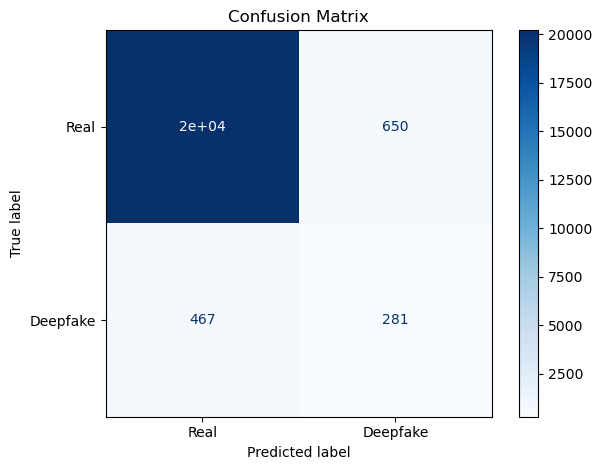

In [45]:
# ══════════════════════════════════════════════════════════════════
# 9. EVALUATION
# ══════════════════════════════════════════════════════════════════
y_true = val_gen.classes
y_prob = model.predict(val_gen, verbose=1).flatten()

# Optimal threshold via F1 sweep
from sklearn.metrics import f1_score
thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores  = [f1_score(y_true, (y_prob > t).astype(int)) for t in thresholds]
best_thresh = thresholds[np.argmax(f1_scores)]
print(f"\nOptimal threshold: {best_thresh:.2f}  (F1={max(f1_scores):.4f})")

y_pred = (y_prob > best_thresh).astype(int)

print("\n" + "═"*50)
print(classification_report(y_true, y_pred,
                             target_names=['Real', 'Deepfake']))
print("═"*50)

cm   = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Real', 'Deepfake'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

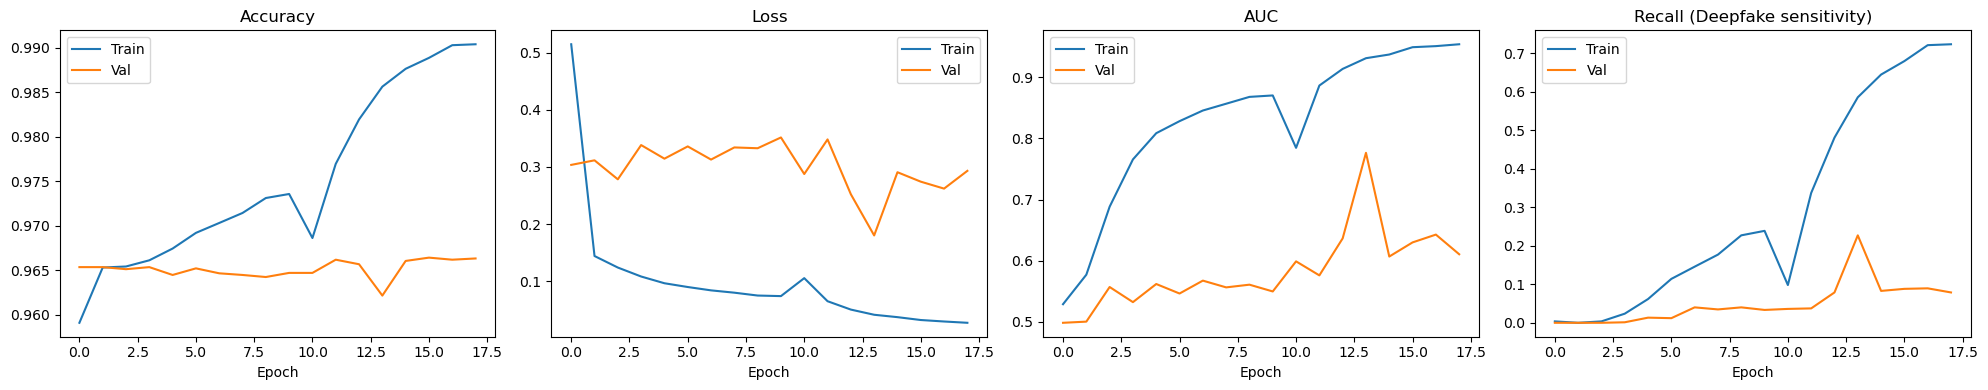

In [47]:
# ══════════════════════════════════════════════════════════════════
# 10. TRAINING CURVES
# ══════════════════════════════════════════════════════════════════
def merge_histories(h1, h2):
    merged = {}
    for k in h1.history:
        merged[k] = h1.history[k] + h2.history[k]
    return merged

history = merge_histories(history1, history2)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
metrics = [
    ('accuracy', 'val_accuracy', 'Accuracy'),
    ('loss',     'val_loss',     'Loss'),
    ('auc',      'val_auc',      'AUC'),
    ('recall',   'val_recall',   'Recall (Deepfake sensitivity)'),
]
for ax, (train_m, val_m, title) in zip(axes, metrics):
    ax.plot(history[train_m], label='Train')
    ax.plot(history[val_m],   label='Val')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
plt.tight_layout()
plt.show()


In [49]:
# ══════════════════════════════════════════════════════════════════
# 11. SINGLE IMAGE PREDICTION (with face detection)
# ══════════════════════════════════════════════════════════════════
def predict_image(image_path, threshold=None):
    """
    Predict whether a single image is Real or Deepfake.
    Uses MTCNN face detection before classifying.
    """
    if threshold is None:
        threshold = best_thresh

    face = extract_face(image_path)
    if face is None:
        print("Could not read image.")
        return None

    face_norm = face.astype(np.float32) / 255.0
    face_batch = np.expand_dims(face_norm, axis=0)

    prob = model.predict(face_batch, verbose=0)[0][0]
    label = 'Deepfake' if prob > threshold else 'Real'
    confidence = prob if prob > threshold else 1 - prob

    # Visualize
    plt.figure(figsize=(4, 4))
    plt.imshow(face)
    color = 'red' if label == 'Deepfake' else 'green'
    plt.title(f"{label}  ({confidence*100:.1f}% confident)", color=color, fontsize=13)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return {'label': label, 'probability': float(prob), 'confidence': float(confidence)}


In [51]:
# ══════════════════════════════════════════════════════════════════
# 12. VIDEO PREDICTION (with face detection per frame)
# ══════════════════════════════════════════════════════════════════
def predict_video(video_path, sample_every=10, threshold=None):
    """
    Predict deepfake probability across video frames.
    Samples every N frames to balance speed vs accuracy.
    """
    if threshold is None:
        threshold = best_thresh

    cap  = cv2.VideoCapture(video_path)
    probs, frame_nums = [], []
    frame_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx % sample_every == 0:
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            detections = detector.detect_faces(rgb)

            if detections:
                best = max(detections, key=lambda d: d['confidence'])
                x, y, w, h = best['box']
                margin = int(0.2 * max(w, h))
                x1, y1 = max(0, x-margin), max(0, y-margin)
                x2, y2 = min(rgb.shape[1], x+w+margin), min(rgb.shape[0], y+h+margin)
                face = rgb[y1:y2, x1:x2]
                face = cv2.resize(face, CONFIG['img_size'])
                face_norm = face.astype(np.float32) / 255.0
                face_batch = np.expand_dims(face_norm, axis=0)
                prob = model.predict(face_batch, verbose=0)[0][0]
                probs.append(prob)
                frame_nums.append(frame_idx)

        frame_idx += 1

    cap.release()

    if not probs:
        print("No faces detected in video.")
        return None

    avg_prob = np.mean(probs)
    label    = 'Deepfake' if avg_prob > threshold else 'Real'
    confidence = avg_prob if avg_prob > threshold else 1 - avg_prob

    # Per-frame probability plot
    plt.figure(figsize=(10, 4))
    plt.plot(frame_nums, probs, alpha=0.6, label='Per-frame probability')
    plt.axhline(threshold, color='red', linestyle='--', label=f'Threshold ({threshold:.2f})')
    plt.axhline(avg_prob,  color='blue', linestyle='-', label=f'Mean ({avg_prob:.3f})')
    plt.fill_between(frame_nums, probs, threshold,
                     where=[p > threshold for p in probs],
                     alpha=0.3, color='red', label='Deepfake frames')
    plt.ylim(0, 1)
    plt.xlabel('Frame')
    plt.ylabel('Deepfake Probability')
    plt.title(f'Video Analysis → {label} ({confidence*100:.1f}% confident)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"\nResult : {label}")
    print(f"Avg probability : {avg_prob:.4f}")
    print(f"Confidence      : {confidence*100:.1f}%")
    print(f"Frames analysed : {len(probs)}")

    return {'label': label, 'avg_probability': float(avg_prob),
            'confidence': float(confidence), 'frame_probs': probs}

# ══════════════════════════════════════════════════════════════════
# USAGE EXAMPLES
# ══════════════════════════════════════════════════════════════════
# Single image:
# result = predict_image('/path/to/image.jpg')

# Video:
# result = predict_video('/path/to/video.mp4', sample_every=10)



In [72]:
conda update scipy -y

python(63894) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Channels:
 - defaults
Platform: osx-arm64
Solving environment: done

## Package Plan ##

  environment location: /opt/anaconda3

  added / updated specs:
    - scipy


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.5.14  |       hca03da5_0         108 KB
    certifi-2026.5.20          |  py311hca03da5_0         131 KB
    conda-24.11.3              |  py311hca03da5_0         1.2 MB
    libcxx-22.1.2              |       hf894667_0         309 KB
    libgfortran-15.2.0         |       h09d7db9_1         130 KB
    libgfortran5-15.2.0        |       hb654fa1_1         742 KB
    libopenblas-0.3.31         |       h7813bb4_2         5.6 MB
    openssl-3.5.7              |       ha0b305a_0         4.7 MB
    scipy-1.17.1               |  py311h079a9ef_1        21.0 MB
    ------------------------------------------------------------
                                      

Imports OK ✓


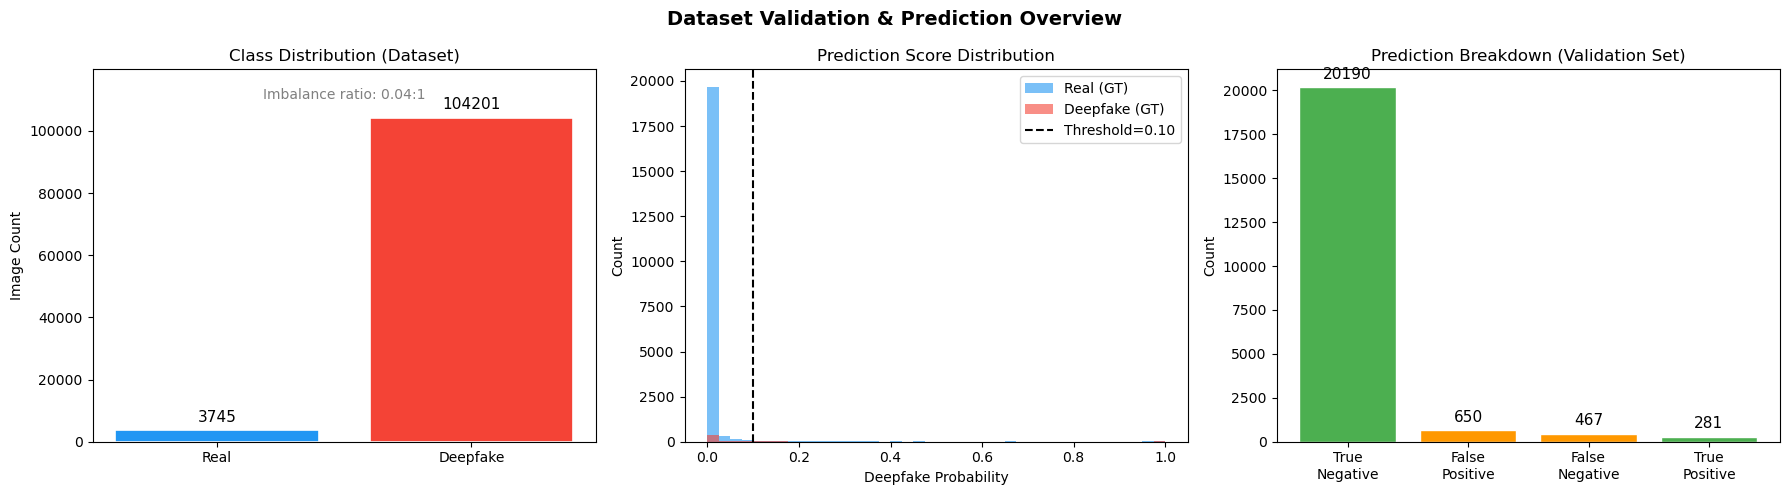

Validation accuracy : 94.83%
False Positive Rate : 3.12%  (Real → predicted Deepfake)
False Negative Rate : 62.43%  (Deepfake → predicted Real)


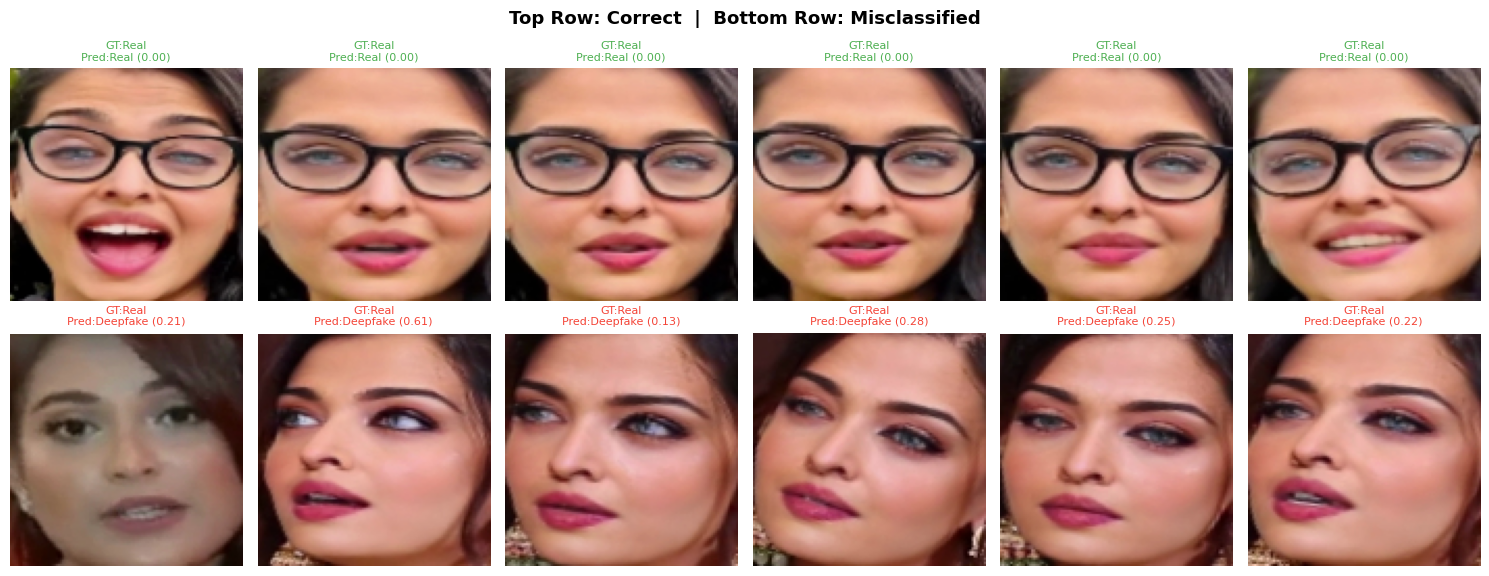

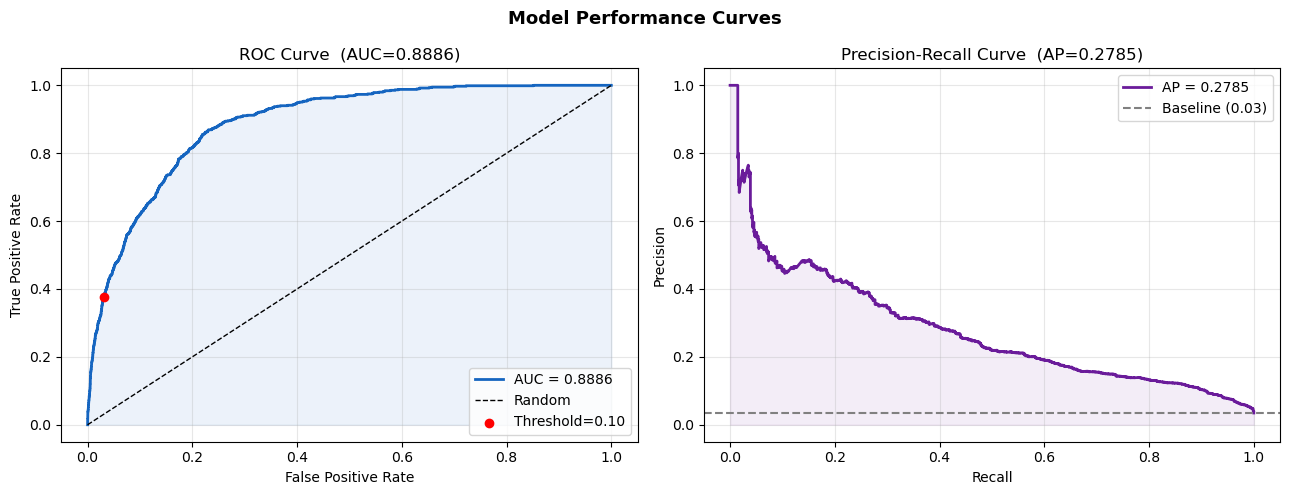

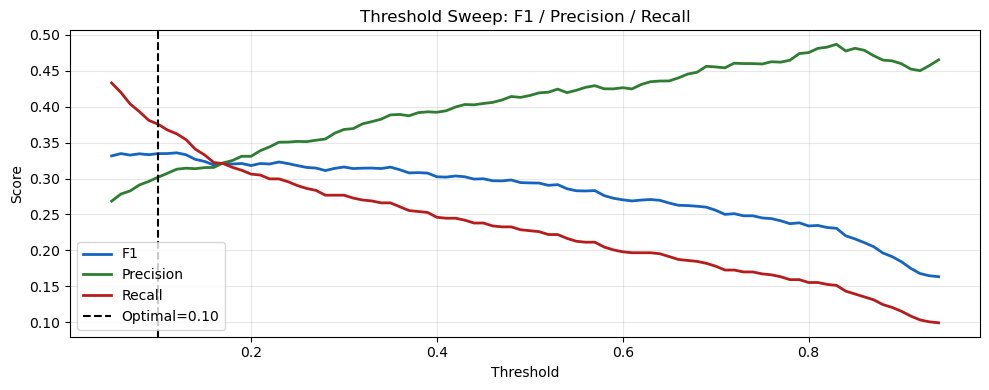

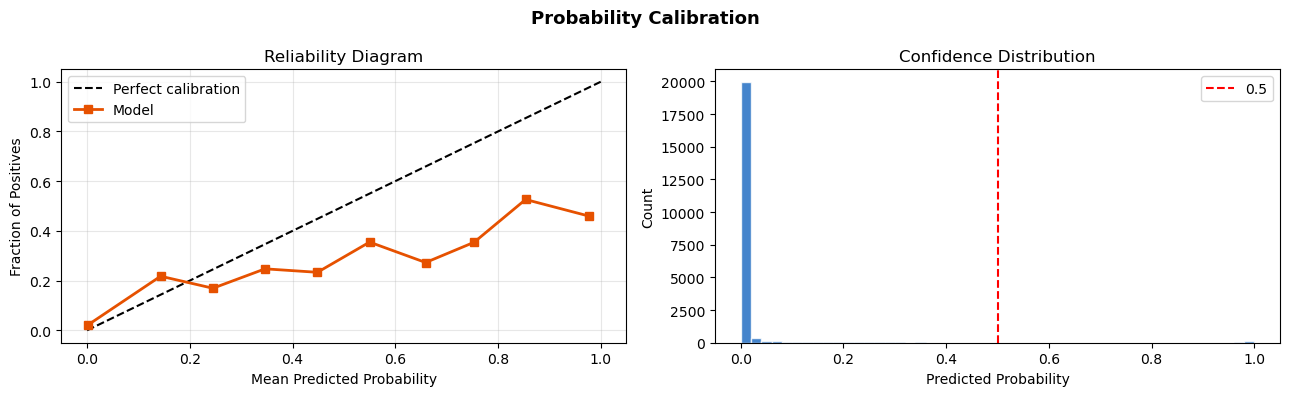

Grad-CAM layer: conv2d_29


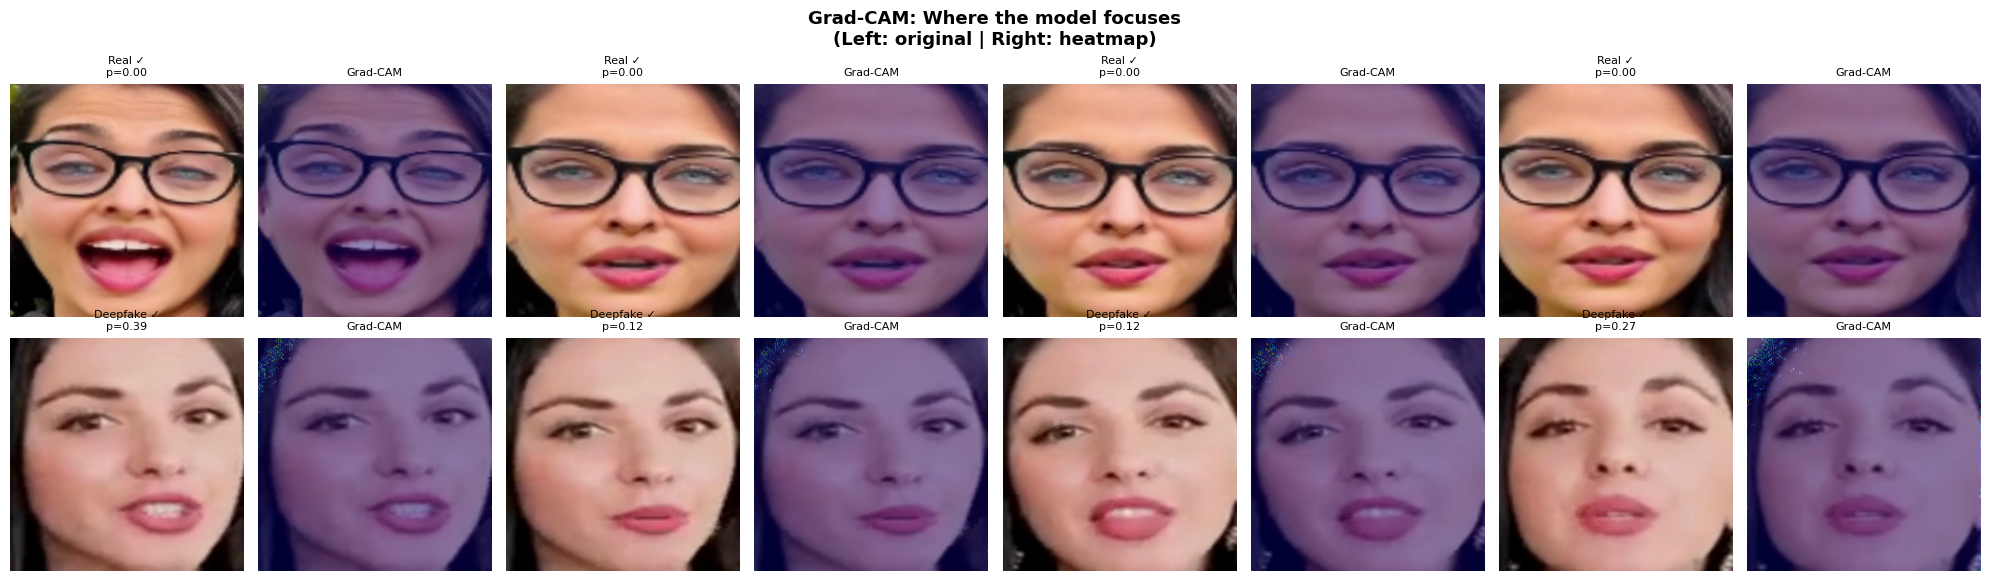

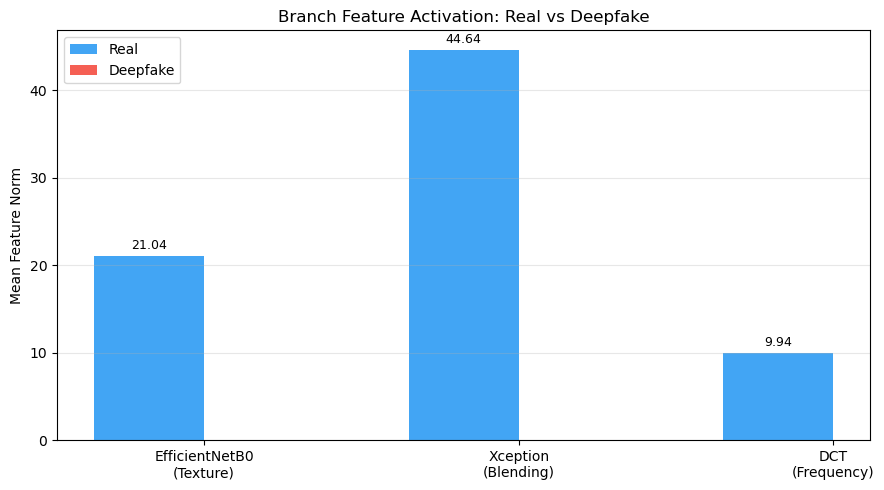

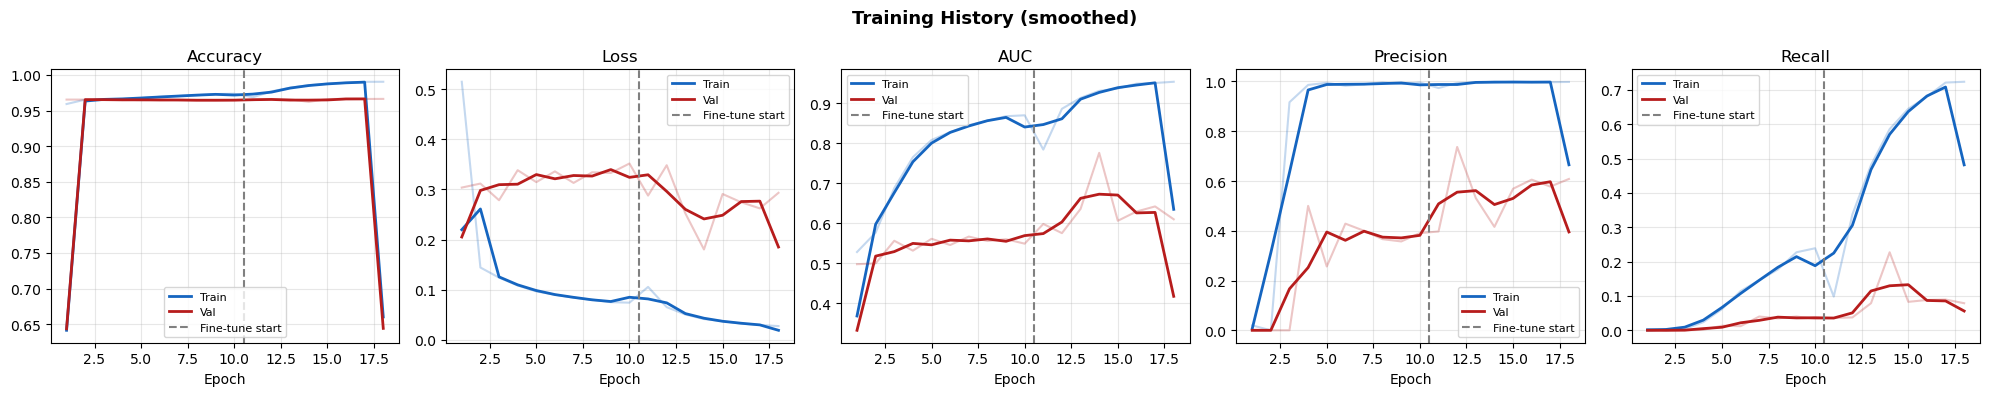


✅  All analyses complete.


In [78]:
# ══════════════════════════════════════════════════════════════════
# ADD-ON ANALYSIS — paste these cells AFTER your last cell
# Requires: model, val_gen, y_true, y_prob, best_thresh, history
#           CONFIG already defined above
# ══════════════════════════════════════════════════════════════════

# ── Extra imports ─────────────────────────────────────────────────
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.calibration import calibration_curve
import warnings
warnings.filterwarnings('ignore')
print("Imports OK ✓")


# ══════════════════════════════════════════════════════════════════
# A. DATASET VALIDATION & CLASS DISTRIBUTION
# ══════════════════════════════════════════════════════════════════

def plot_dataset_overview(parent_dir, val_gen, y_true, y_prob, best_thresh):
    real_dir   = os.path.join(parent_dir, 'real')
    fake_dir   = os.path.join(parent_dir, 'deepfake')
    real_count = len(os.listdir(real_dir))
    fake_count = len(os.listdir(fake_dir))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Dataset Validation & Prediction Overview', fontsize=14, fontweight='bold')

    # 1. Class balance
    ax = axes[0]
    bars = ax.bar(['Real', 'Deepfake'], [real_count, fake_count],
                  color=['#2196F3', '#F44336'], edgecolor='white', linewidth=1.2)
    ax.bar_label(bars, fmt='%d', padding=4, fontsize=11)
    ax.set_title('Class Distribution (Dataset)')
    ax.set_ylabel('Image Count')
    ax.set_ylim(0, max(real_count, fake_count) * 1.15)
    ratio = real_count / fake_count if fake_count else float('inf')
    ax.text(0.5, 0.92, f'Imbalance ratio: {ratio:.2f}:1',
            ha='center', transform=ax.transAxes, fontsize=10, color='gray')

    # 2. Prediction score distribution
    ax = axes[1]
    ax.hist(y_prob[y_true == 0], bins=40, alpha=0.6, color='#2196F3', label='Real (GT)')
    ax.hist(y_prob[y_true == 1], bins=40, alpha=0.6, color='#F44336', label='Deepfake (GT)')
    ax.axvline(best_thresh, color='black', linestyle='--', linewidth=1.5,
               label=f'Threshold={best_thresh:.2f}')
    ax.set_title('Prediction Score Distribution')
    ax.set_xlabel('Deepfake Probability')
    ax.set_ylabel('Count')
    ax.legend()

    # 3. TP/TN/FP/FN breakdown
    ax = axes[2]
    y_pred_thresh = (y_prob > best_thresh).astype(int)
    tp = int(np.sum((y_pred_thresh == 1) & (y_true == 1)))
    tn = int(np.sum((y_pred_thresh == 0) & (y_true == 0)))
    fp = int(np.sum((y_pred_thresh == 1) & (y_true == 0)))
    fn = int(np.sum((y_pred_thresh == 0) & (y_true == 1)))
    labels = ['True\nNegative', 'False\nPositive', 'False\nNegative', 'True\nPositive']
    values = [tn, fp, fn, tp]
    colors = ['#4CAF50', '#FF9800', '#FF9800', '#4CAF50']
    b = ax.bar(labels, values, color=colors, edgecolor='white')
    ax.bar_label(b, fmt='%d', padding=4, fontsize=11)
    ax.set_title('Prediction Breakdown (Validation Set)')
    ax.set_ylabel('Count')

    plt.tight_layout()
    plt.show()
    print(f"Validation accuracy : {(tp+tn)/(tp+tn+fp+fn)*100:.2f}%")
    print(f"False Positive Rate : {fp/(fp+tn)*100:.2f}%  (Real → predicted Deepfake)")
    print(f"False Negative Rate : {fn/(fn+tp)*100:.2f}%  (Deepfake → predicted Real)")

plot_dataset_overview(CONFIG['parent_dir'], val_gen, y_true, y_prob, best_thresh)


# ══════════════════════════════════════════════════════════════════
# B. SAMPLE GRID — Correct vs Misclassified
# ══════════════════════════════════════════════════════════════════

def show_sample_grid(val_gen, y_true, y_prob, best_thresh, n=6):
    y_pred        = (y_prob > best_thresh).astype(int)
    correct_idx   = np.where(y_pred == y_true)[0]
    incorrect_idx = np.where(y_pred != y_true)[0]
    label_map     = {0: 'Real', 1: 'Deepfake'}

    fig, axes = plt.subplots(2, n, figsize=(n * 2.5, 6))
    fig.suptitle('Top Row: Correct  |  Bottom Row: Misclassified',
                 fontsize=13, fontweight='bold')

    def plot_sample(ax, idx):
        img_path = val_gen.filepaths[idx]
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (112, 112))
        ax.imshow(img)
        gt    = label_map[y_true[idx]]
        pred  = label_map[y_pred[idx]]
        prob  = y_prob[idx]
        color = '#4CAF50' if gt == pred else '#F44336'
        ax.set_title(f'GT:{gt}\nPred:{pred} ({prob:.2f})', fontsize=8, color=color)
        ax.axis('off')

    for i, idx in enumerate(correct_idx[:n]):
        plot_sample(axes[0, i], idx)
    for i, idx in enumerate(incorrect_idx[:n]):
        plot_sample(axes[1, i], idx)

    plt.tight_layout()
    plt.show()

show_sample_grid(val_gen, y_true, y_prob, best_thresh)


# ══════════════════════════════════════════════════════════════════
# C. ROC + PRECISION-RECALL CURVES
# ══════════════════════════════════════════════════════════════════

def plot_roc_pr_curves(y_true, y_prob, best_thresh):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle('Model Performance Curves', fontsize=13, fontweight='bold')

    # ROC
    fpr, tpr, roc_thresh = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    ax = axes[0]
    ax.plot(fpr, tpr, color='#1565C0', lw=2, label=f'AUC = {roc_auc:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
    best_idx = np.argmin(np.abs(roc_thresh - best_thresh))
    ax.scatter(fpr[best_idx], tpr[best_idx], color='red', zorder=5,
               label=f'Threshold={best_thresh:.2f}')
    ax.fill_between(fpr, tpr, alpha=0.08, color='#1565C0')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve  (AUC={roc_auc:.4f})')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)

    # Precision-Recall
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    ax = axes[1]
    ax.plot(recall, precision, color='#6A1B9A', lw=2, label=f'AP = {ap:.4f}')
    baseline = y_true.mean()
    ax.axhline(baseline, color='gray', linestyle='--', label=f'Baseline ({baseline:.2f})')
    ax.fill_between(recall, precision, alpha=0.08, color='#6A1B9A')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'Precision-Recall Curve  (AP={ap:.4f})')
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_roc_pr_curves(y_true, y_prob, best_thresh)


# ══════════════════════════════════════════════════════════════════
# D. THRESHOLD SWEEP — F1 / Precision / Recall vs Threshold
# ══════════════════════════════════════════════════════════════════

def plot_threshold_sweep(y_true, y_prob, best_thresh):
    from sklearn.metrics import precision_score, recall_score
    thresholds = np.arange(0.05, 0.95, 0.01)
    f1s, precs, recs = [], [], []
    for t in thresholds:
        yp = (y_prob > t).astype(int)
        f1s.append(f1_score(y_true, yp, zero_division=0))
        precs.append(precision_score(y_true, yp, zero_division=0))
        recs.append(recall_score(y_true, yp, zero_division=0))

    plt.figure(figsize=(10, 4))
    plt.plot(thresholds, f1s,   label='F1',       color='#1565C0', lw=2)
    plt.plot(thresholds, precs, label='Precision', color='#2E7D32', lw=2)
    plt.plot(thresholds, recs,  label='Recall',    color='#B71C1C', lw=2)
    plt.axvline(best_thresh, color='black', linestyle='--', lw=1.5,
                label=f'Optimal={best_thresh:.2f}')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title('Threshold Sweep: F1 / Precision / Recall')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_threshold_sweep(y_true, y_prob, best_thresh)


# ══════════════════════════════════════════════════════════════════
# E. CALIBRATION CURVE (Reliability Diagram)
# ══════════════════════════════════════════════════════════════════

def plot_calibration(y_true, y_prob):
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy='uniform')

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle('Probability Calibration', fontsize=13, fontweight='bold')

    ax = axes[0]
    ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
    ax.plot(prob_pred, prob_true, 's-', color='#E65100', lw=2, label='Model')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title('Reliability Diagram')
    ax.legend()
    ax.grid(alpha=0.3)

    ax = axes[1]
    ax.hist(y_prob, bins=50, color='#1565C0', edgecolor='white', alpha=0.8)
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Count')
    ax.set_title('Confidence Distribution')
    ax.axvline(0.5, color='red', linestyle='--', label='0.5')
    ax.legend()

    plt.tight_layout()
    plt.show()

plot_calibration(y_true, y_prob)


# ══════════════════════════════════════════════════════════════════
# F. GRAD-CAM — Where does the model look? (XAI)
# ══════════════════════════════════════════════════════════════════

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_channel = predictions[:, 0]
    grads       = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap     = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap     = tf.squeeze(heatmap)
    heatmap     = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_gradcam(img_rgb, heatmap, alpha=0.4):
    heatmap_resized = cv2.resize(heatmap, (img_rgb.shape[1], img_rgb.shape[0]))
    heatmap_uint8   = np.uint8(255 * heatmap_resized)
    colormap        = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    colormap_rgb    = cv2.cvtColor(colormap, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(img_rgb, 1 - alpha, colormap_rgb, alpha, 0)


def plot_gradcam_grid(val_gen, model, y_true, y_prob, best_thresh,
                      last_conv_layer, n=4):
    y_pred   = (y_prob > best_thresh).astype(int)
    real_idx = np.where((y_true == 0) & (y_pred == 0))[0][:n]
    fake_idx = np.where((y_true == 1) & (y_pred == 1))[0][:n]

    fig, axes = plt.subplots(2, n * 2, figsize=(n * 5, 6))
    fig.suptitle('Grad-CAM: Where the model focuses\n(Left: original | Right: heatmap)',
                 fontsize=13, fontweight='bold')

    def process_one(idx, row, col_offset, label_str):
        img_path = val_gen.filepaths[idx]
        img_rgb  = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        img_rgb  = cv2.resize(img_rgb, CONFIG['img_size'])
        img_norm = img_rgb.astype(np.float32) / 255.0
        img_batch = np.expand_dims(img_norm, 0)
        try:
            heatmap = make_gradcam_heatmap(img_batch, model, last_conv_layer)
            overlay = overlay_gradcam(img_rgb, heatmap)
        except Exception:
            overlay = img_rgb
        axes[row, col_offset].imshow(img_rgb)
        axes[row, col_offset].set_title(f'{label_str}\np={y_prob[idx]:.2f}', fontsize=8)
        axes[row, col_offset].axis('off')
        axes[row, col_offset + 1].imshow(overlay)
        axes[row, col_offset + 1].set_title('Grad-CAM', fontsize=8)
        axes[row, col_offset + 1].axis('off')

    for i, idx in enumerate(real_idx):
        process_one(idx, row=0, col_offset=i * 2, label_str='Real ✓')
    for i, idx in enumerate(fake_idx):
        process_one(idx, row=1, col_offset=i * 2, label_str='Deepfake ✓')

    plt.tight_layout()
    plt.show()


def find_last_conv(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    return None

last_conv = find_last_conv(model)
print(f"Grad-CAM layer: {last_conv}")
plot_gradcam_grid(val_gen, model, y_true, y_prob, best_thresh,
                  last_conv_layer=last_conv)


# ══════════════════════════════════════════════════════════════════
# G. BRANCH CONTRIBUTION ANALYSIS
# ══════════════════════════════════════════════════════════════════

def plot_branch_contributions(model, val_gen, n_batches=3):
    """
    Compare feature norm from each branch (EfficientNet / Xception / DCT)
    for Real vs Deepfake samples.
    """
    fusion_layer  = model.get_layer('fusion')
    input_tensors = fusion_layer.input
    branch_model  = tf.keras.Model(inputs=model.input, outputs=input_tensors)

    real_norms = [[], [], []]
    fake_norms = [[], [], []]

    for count, (imgs, lbls) in enumerate(val_gen):
        outputs = branch_model.predict(imgs, verbose=0)
        for b in range(3):
            norms = np.linalg.norm(outputs[b], axis=-1)
            for j, lbl in enumerate(lbls):
                (real_norms if lbl == 0 else fake_norms)[b].append(norms[j])
        if count + 1 >= n_batches:
            break

    branch_labels = ['EfficientNetB0\n(Texture)', 'Xception\n(Blending)', 'DCT\n(Frequency)']
    real_means = [np.mean(real_norms[b]) for b in range(3)]
    fake_means = [np.mean(fake_norms[b]) for b in range(3)]

    x, width = np.arange(3), 0.35
    fig, ax = plt.subplots(figsize=(9, 5))
    b1 = ax.bar(x - width/2, real_means, width, label='Real',     color='#2196F3', alpha=0.85)
    b2 = ax.bar(x + width/2, fake_means, width, label='Deepfake', color='#F44336', alpha=0.85)
    ax.bar_label(b1, fmt='%.2f', padding=3, fontsize=9)
    ax.bar_label(b2, fmt='%.2f', padding=3, fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(branch_labels)
    ax.set_ylabel('Mean Feature Norm')
    ax.set_title('Branch Feature Activation: Real vs Deepfake')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

try:
    plot_branch_contributions(model, val_gen)
except Exception as e:
    print(f"Branch contribution skipped: {e}")


# ══════════════════════════════════════════════════════════════════
# H. EXTENDED TRAINING CURVES (smoothed + stage marker)
# ══════════════════════════════════════════════════════════════════

def plot_extended_training(history, stage1_epochs=10):
    def smooth(y, pts=3):
        return np.convolve(y, np.ones(pts) / pts, mode='same')

    metrics = [
        ('accuracy',  'val_accuracy',  'Accuracy'),
        ('loss',      'val_loss',      'Loss'),
        ('auc',       'val_auc',       'AUC'),
        ('precision', 'val_precision', 'Precision'),
        ('recall',    'val_recall',    'Recall'),
    ]
    metrics = [(t, v, l) for t, v, l in metrics if t in history and v in history]
    n = len(metrics)

    fig, axes = plt.subplots(1, n, figsize=(n * 4, 4))
    fig.suptitle('Training History (smoothed)', fontsize=13, fontweight='bold')
    if n == 1:
        axes = [axes]

    for ax, (tm, vm, title) in zip(axes, metrics):
        t_vals = history[tm]
        v_vals = history[vm]
        epochs = range(1, len(t_vals) + 1)
        ax.plot(epochs, t_vals,         alpha=0.25, color='#1565C0')
        ax.plot(epochs, smooth(t_vals), color='#1565C0', lw=2, label='Train')
        ax.plot(epochs, v_vals,         alpha=0.25, color='#B71C1C')
        ax.plot(epochs, smooth(v_vals), color='#B71C1C', lw=2, label='Val')
        if stage1_epochs < len(t_vals):
            ax.axvline(stage1_epochs + 0.5, color='gray', linestyle='--',
                       lw=1.5, label='Fine-tune start')
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_extended_training(history, stage1_epochs=10)

print("\n✅  All analyses complete.")